In [112]:
import matplotlib.pyplot as plt
import numpy as np
import pyreaper
import scipy.io.wavfile as wavfile
import wave
from scipy.signal import get_window
from statsmodels.tsa.stattools import acf
from typing import Tuple

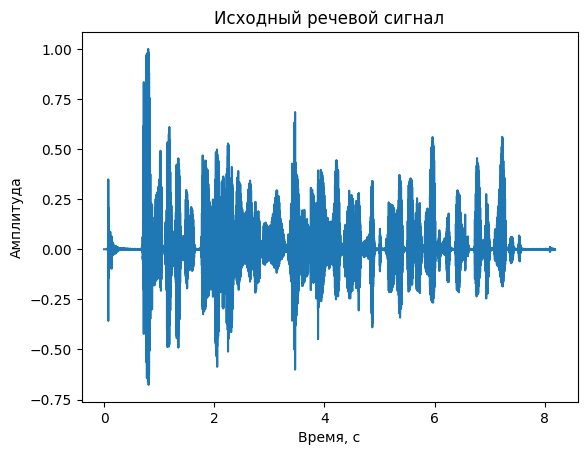

Частота дискретизации: 48000 Гц
Длина сигнала (в отсчётах): 392832
Длительность (в секундах): 8.184


In [113]:
fs, x = wavfile.read("input.wav")

# Если стерео — берём только один канал
if x.ndim > 1:
    x = x[:, 0]

# Нормализация
x = x.astype(np.float32)
x = x / np.max(np.abs(x))
n = len(x)
t = np.linspace(0, len(x) / fs, len(x))
plt.figure()
plt.plot(t, x)
plt.title("Исходный речевой сигнал")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()
print("Частота дискретизации:", fs, "Гц")
print("Длина сигнала (в отсчётах):", n)
print("Длительность (в секундах):", n/fs)

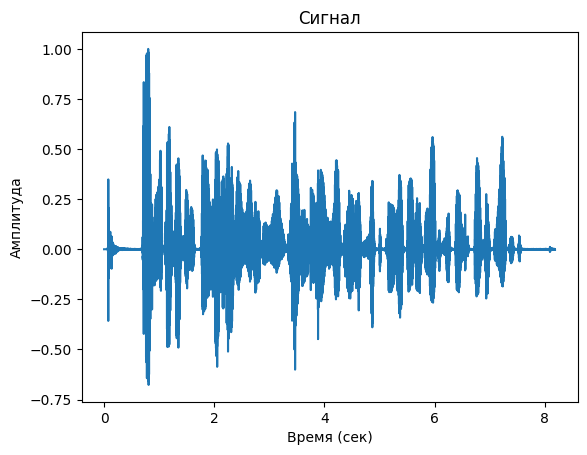

In [114]:
time = np.linspace(0, (n - 1) / fs, n)
plt.plot(time, x)
plt.title("Сигнал")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.show()

### АКФ:

In [115]:
def my_acf(x, m):
    mean = np.mean(x)
    var = np.var(x)

    n = x.size
    x1 = x[:n-m].astype(np.float64) - mean
    x2 = x[m:n].astype(np.float64) - mean

    return np.sum(x1 * x2) / ((n - m) * var)

In [116]:
acf_values = acf(x, adjusted=True, nlags=1000)

In [117]:
print(my_acf(x, 0), acf_values[0])
print(my_acf(x, 100), acf_values[100])
print(my_acf(x, 350), acf_values[350])
print(my_acf(x, 500), acf_values[500])

0.9999999049220986 1.0
-0.10855842953725772 -0.10855843967954996
-0.1103684370383582 -0.1103684468938366
-0.07764645692451318 -0.07764646366539946


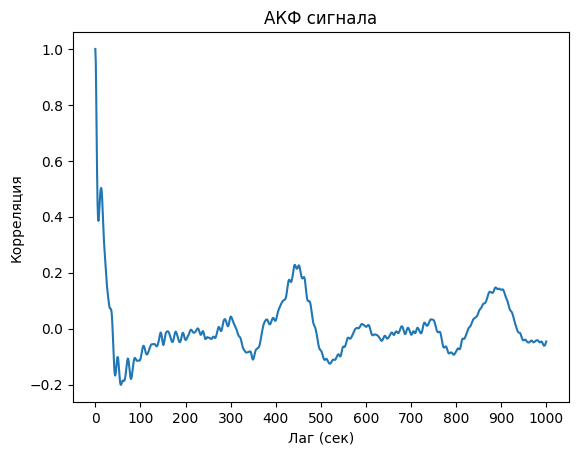

In [118]:
n_acf = len(acf_values)
t = np.linspace(0, n_acf, n_acf)
plt.xticks(np.arange(0, n_acf, step=100))
plt.plot(acf_values)
plt.title("АКФ сигнала")
plt.xlabel("Лаг (сек)")
plt.ylabel("Корреляция")
plt.show()

In [119]:
start = 100
m_max_index = np.argmax(acf_values[start:]) + start
print(m_max_index)

442


In [120]:
f_tone_acf = int(fs / m_max_index)
print('Основная частота:', f_tone_acf)

Основная частота: 108


### DTFT

In [ ]:
def my_dtft(x: np.ndarray, f: np.ndarray, fs: int) -> np.ndarray:
    """
    Вычисляет Дискретное Временное Преобразование Фурье (ДВПФ) для сигнала x на заданных частотах f.
    
    Параметры:
        x (np.ndarray): Входной сигнал (временной ряд)
        f (np.ndarray): Массив частот, для которых вычисляется ДВПФ (в герцах)
        fs (int): Частота дискретизации сигнала (в герцах)
    
    Возвращает:
        np.ndarray: Амплитудный спектр сигнала на заданных частотах
    """
    
    # 1. Создание массива временных точек [0, 1, 2, ..., N-1], где N - длина сигнала
    points = np.arange(0, x.size, 1)
    
    # 2. Подготовка комплексных множителей для экспоненты:
    #    - (-1j) для отрицательной мнимой части в экспоненте
    #    - 2π для перевода в угловые частоты
    #    - Деление на fs для нормировки по времени t = n/fs
    complex_points = (points * (-1j) * 2*np.pi) / fs
    
    # 3. Создание матрицы аргументов экспоненты:
    #    Внешнее произведение частот и временных множителей дает матрицу,
    #    где каждая строка соответствует своей частоте,
    #    а каждый столбец - своему временному отсчету
    args_exp = np.outer(f, complex_points)
    
    # 4. Вычисление матрицы комплексных экспонент:
    #    Каждый элемент матрицы = exp(-j*2π*f_k*t_n),
    #    где f_k - частота из массива f,
    #    t_n = n/fs - момент времени n-го отсчета
    exp_arr = np.exp(args_exp)
    
    # 5. Вычисление ДВПФ:
    #    - Умножение матрицы экспонент на вектор сигнала (скалярное произведение)
    #    - Взятие модуля для получения амплитудного спектра
    return np.abs(np.dot(exp_arr, x))

In [122]:
start = 50
stop = 300
f = np.arange(start, stop, 1)
F = my_dtft(x, f, fs)

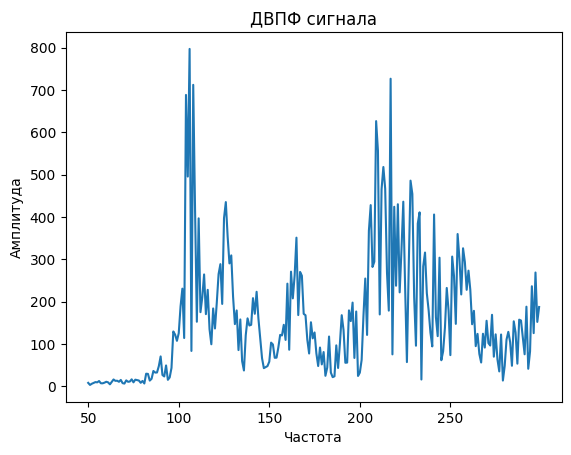

In [123]:
plt.xticks(np.arange(start, stop, step=50))
plt.title("ДВПФ сигнала")
plt.xlabel("Частота")
plt.ylabel("Амплитуда")
plt.plot(f, F)
plt.show()

In [124]:
f_tone_dtft = np.argmax(F[:150]) + start
print('Fundamental frequency by DTFT:', f_tone_dtft)

Fundamental frequency by DTFT: 106


### Google REAPER

In [ ]:
# Создаем копию входного сигнала, чтобы не изменять оригинальные данные
signal_copy = x.copy()

# Создаем массив временных меток для сигнала:
# - от 0 до (n-1)/fs (длительность сигнала в секундах)
# - всего n точек, равномерно распределенных
t = np.linspace(0, (n - 1) / fs, n)

# Получаем информацию о типе данных int16 (минимальное и максимальное значения)
int16_info = np.iinfo(np.int16) 

# Масштабируем сигнал перед преобразованием в int16:
# Умножаем на минимальное из (минимального или максимального) значений int16,
# чтобы избежать переполнения при конвертации
signal_copy = signal_copy * min(int16_info.min, int16_info.max) 

# Конвертируем сигнал в 16-битный целочисленный формат (стандартный для аудио)
signal_copy = signal_copy.astype(np.int16)

# Выполняем анализ сигнала с помощью REAPER (Robust Epoch And Pitch EstimatoR):
# - signal_copy: входной сигнал в int16
# - fs: частота дискретизации
# - maxf0: максимальная частота основного тона для поиска (300 Гц)
# - do_hilbert_transform: выполнять преобразование Гильберта (True)
# - do_high_pass: выполнять высокочастотную фильтрацию (False)
# - unvoiced_cost: параметр стоимости для неозвученных участков (0.6)
pm_times, pm, f_times, f, correlation = pyreaper.reaper(
    signal_copy, fs, 
    maxf0=300, 
    do_hilbert_transform=True, 
    do_high_pass=False, 
    unvoiced_cost=0.6
)

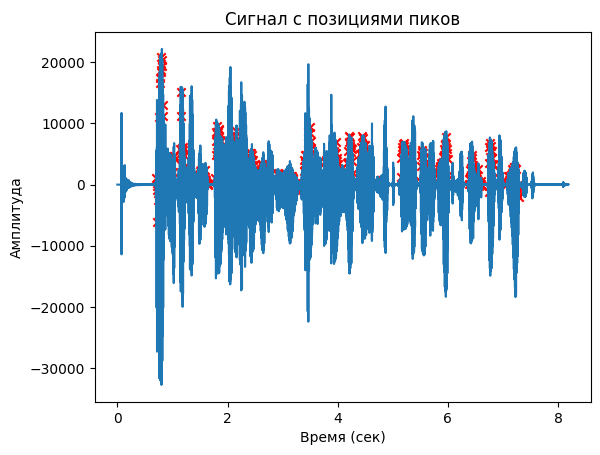

In [126]:
plt.title("Сигнал с позициями пиков")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.plot(t, signal_copy) 
plt.scatter(pm_times[pm == 1], signal_copy[(pm_times * fs).astype(int)][pm == 1], marker='x', color='red')

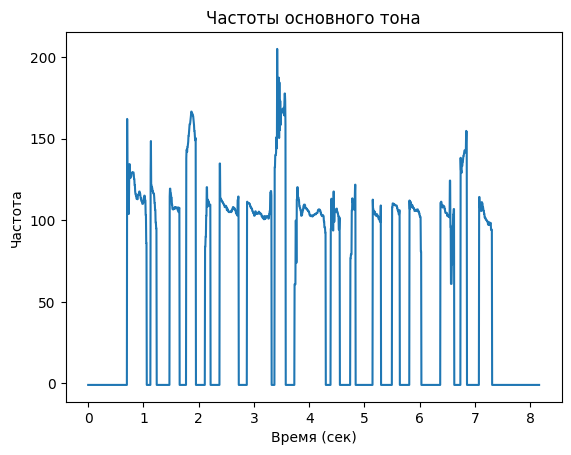

In [127]:
plt.title("Частоты основного тона")
plt.xlabel("Время (сек)")
plt.ylabel("Частота")
plt.plot(f_times, f)
plt.show()

In [128]:
f_tone_reaper = int(np.mean(f[f != -1]))
print('Fundamental frequency by REAPER:', f_tone_reaper)

Fundamental frequency by REAPER: 112


### PSOLA

In [ ]:
def psola(x: np.ndarray, fs: int, k: float) -> np.ndarray:
    """
    Реализация алгоритма PSOLA для модификации высоты тона (pitch shifting) сигнала.
    
    Параметры:
        x (np.ndarray): Входной аудиосигнал
        fs (int): Частота дискретизации (в Гц)
        k (float): Коэффициент изменения тона (1.0 - оригинал, >1.0 - выше, <1.0 - ниже)
    
    Возвращает:
        np.ndarray: Модифицированный сигнал (в формате int16)
    """
    
    # 1. Анализ сигнала с помощью REAPER для получения меток основного тона
    pm_times, pm, f_times, f0, correlation = pyreaper.reaper(
        x, fs, 
        maxf0=300,                   # Максимальная частота основного тона
        do_hilbert_transform=True,   # Использовать преобразование Гильберта
        do_high_pass=True,           # Применить высокочастотную фильтрацию
        unvoiced_cost=1.5            # Параметр для неозвученных участков
    )
    
    # 2. Фильтрация только озвученных участков (где f0 > 0)
    voiced_mask = (f0 > 0)
    f0 = f0[voiced_mask]
    f_times = f_times[voiced_mask]
    
    # 3. Расчет периодов основного тона и их модификация
    T0 = 1 / f0      # Периоды основного тона (в секундах)
    T0 *= k          # Масштабирование периодов согласно коэффициенту k
    
    # 4. Подготовка выходного сигнала
    y = np.zeros_like(x, dtype=np.float32)
    
    # 5. Основной цикл PSOLA
    for i in range(1, len(f_times) - 1):
        # 5.1 Определение границ сегмента в оригинальном сигнале
        start = int(f_times[i] * fs - T0[i] * fs / 2)
        end = int(f_times[i] * fs + T0[i] * fs / 2)
        
        # Пропуск сегментов, выходящих за границы сигнала
        if start < 0 or end >= len(x):
            continue
        
        # 5.2 Извлечение сегмента сигнала
        segment = x[start:end]
        
        # 5.3 Применение оконной функции (Блэкмана) для сглаживания
        window = get_window("blackman", len(segment))
        segment = segment * window
        
        # 5.4 Расчет новой позиции для сегмента
        new_center = int(f_times[i] * fs * k)
        new_start = new_center - len(segment) // 2
        new_end = new_center + len(segment) // 2
        
        # Пропуск сегментов, выходящих за границы нового сигнала
        if new_start < 0 or new_end >= len(y):
            continue
        
        # 5.5 Добавление сегмента в новую позицию
        segment = segment[:new_end - new_start]  # Обрезка по границам
        y[new_start:new_end] += segment         # Наложение с перекрытием
    
    # 6. Возврат результата в 16-битном формате
    return y.astype(np.int16)

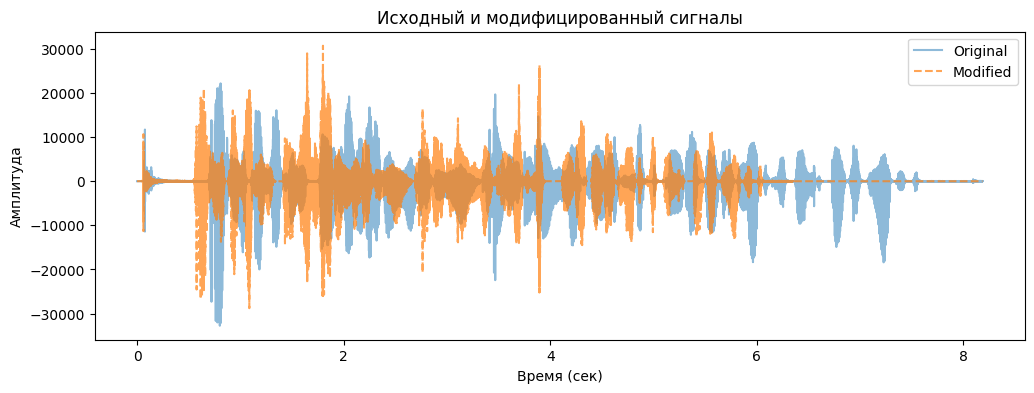

In [130]:
int16_info = np.iinfo(np.int16) 
x = x * min(int16_info.min, int16_info.max) 
x = x.astype(np.int16)

k = 0.8
signal_new = psola(x, fs, k)

wavfile.write("sound_psola.wav", fs, signal_new)

plt.figure(figsize=(12, 4))
plt.plot(time, x, alpha=0.5, label='Original')
plt.plot(time, signal_new, alpha=0.7, label='Modified', linestyle='dashed')
plt.title("Исходный и модифицированный сигналы")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()